<!-- HTML file automatically generated from DocOnce source (https://github.com/doconce/doconce/)
doconce format html final.do.txt --no_mako -->
<!-- dom:TITLE: PHY321 Classical Mechanics 1 -->

# PHY321 Classical Mechanics 1
**Final  project Spring semester 2023, due Friday May 5**, midnight (1159pm)

Date: **April 26, 2023**

# Siddak And Agrim

## Practicalities about  homeworks and projects (midterms and final)

1. You can work in groups (optimal groups are often 2-3 people) or by yourself. If you work as a group you can hand in one answer only if you wish. **Remember to write your name(s)**!

2. How do I(we)  hand in?  Due to the extraordinary situation we are in now, the final projec should be handed in fully via D2L. You can scan your handwritten notes and upload to D2L or you can hand in everyhting (if you are ok with typing mathematical formulae using say Latex) as a jupyter notebook at D2L. The numerical part should always be handed in as a jupyter notebook.

### Introduction to the final project, total score: 160  points

The relevant reading background is
1. Chapters 2-8 and 14 of Taylor

2. Lecture notes throughout the semester and homework assignments and midterm projects.

### Exercise 1, motion of a balloon (75pt)

This exercise brings us back to the beginning of the semester and
homework assignments 2 and 3, in particular exercises 5 and 6 of
homework 3. The relevant chapter of Taylor's text is chapter 2 and
partly chapter 3. The code you wrote for homework 3 may be useful.

In this exercise we will develop a model to determine the motion of a
weather balloon released from the ground. We start from a simplified
model and gradually add features to make our model more realistic.

After the balloon is released, it is driven by buoyancy. Initially, we will assume that the buoyancy force is given by a constant force, $\boldsymbol{B}$.
We assume that the motion is vertical only and label this in terms of the $z$-axis.  That is our system is one-dimensional only.
The constant buoyancy force is then given by its $z$-component only, that is $\boldsymbol{B}=B_z\boldsymbol{k}$, where $\boldsymbol{k}$ is the unit vector along the $z$-axis.
* **1a (5pt)**: Draw a diagram of the balloon and identify and label the forces. 

* **1b (5pt)**: We neglect air resistance here. What is the acceleration of the balloon?

* **1c (5pt)**: Find the position and velocity of the balloon as a function of time.

Let us now introduce air resistance, using a quadratic law: $\boldsymbol{F}_D
= −D \vert \boldsymbol{v}\vert \boldsymbol{v}$, where $D$ is a constant and $\boldsymbol{v}$
is the velocity. We are still in one dimension but have introduced
forces and velocities as vectors (boldfaced quantities).

* **1d (5pt):** Show that the acceleration of the balloon in the upward $z$ direction is $a_z = (B_z/m)−g−(D/m)|v_z|v_z$,where $v_z$ is the velocity in the $z$-direction.

* **1e (5pt):** Find the asymptotic (terminal) velocity of the balloon. Sketch the acceleration and velocity as a function of time for the model including air resistance and define the initial conditions.

The balloon is released on a windy day, with a wind blowing with a velocity
given by $\boldsymbol{w} = w_x \boldsymbol{i}$ along the horizontal $x$-axis.

* **1f (5pt):** How does the wind modify the air resistance force $\boldsymbol{F}_D$ on the balloon?

* **1g (5pt):** Draw a diagram of the system (the balloon) in this case and identify and label the forces, as you did in **1a**.

* **1h (5pt):** Find an expression for the acceleration $\boldsymbol{a}$ of the balloon. Define the initial conditions for the motion of the balloon.

* **1i (5pt):** Why do we call the motion in the $z$ and the $x$ directions as *coupled* in this case? Can you determine the motion of the balloon analytically?

* **1j (20pt):** Use now your codes from homework 3 or similar and find the velocity and position of the balloon as functions of time. Plot the position and the velocity with chosen initial conditions and discuss the motion of the balloon. Find the asymptotic (terminal) velocity of the balloon.

In a real situation, the wind velocity is smaller near the ground and
increases gradually to the full velocity $w_0$ as the balloon moves
upward. Typically, the velocity of the wind as function of the height $z$ can be described
by

$$
\boldsymbol{w}(z) = w_0 (1−\exp{(−z/d)}) \boldsymbol{i},
$$

where $d = 10$m is a length determining the change in height.

* **1k (10pt):** Rewrite your program to include this effect and plot the velocity and position as functions of time. What is the terminal velocity of the balloon now?

# 1j

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
D = 1
m = 1
delta_t = 0.01
g = np.array([0,9.81])
Bz = np.array([0,50])
tfinal = 50
n = int(tfinal/delta_t)
v_ter = np.sqrt((Bz-m*g)/D)
t = np.zeros(n)
wx = -1*np.ones(n)
vz = np.zeros(n)
z = np.zeros(n)

for i in range(len(t)-1):
    F_D = -D * np.sqrt(wx[i]**2 + vz[i]**2) * np.array([-wx[i], vz[i]])
    F_gravity = -m*g
    F_net = F_D + Bz + F_gravity
    a = F_net/m
    vz[i+1] = vz[i] + a[1]*delta_t
    z[i+1] = z[i] + vz[i+1]*delta_t + (Bz[1]/(2*m))*delta_t**2 - 0.5*g[1]*delta_t**2
    t[i+1] = t[i]+delta_t



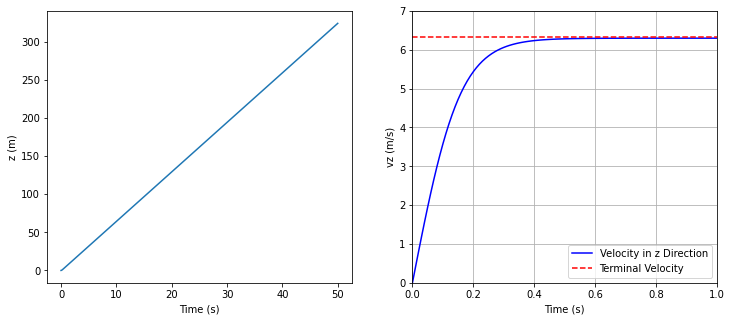

In [4]:
fig, axes = plt.subplots(1,2)
fig.set_size_inches(12,5)
axes[0].plot(t, z)
axes[0].set_ylabel('z (m)')
axes[0].set_xlabel('Time (s)')
axes[1].plot(t, vz, color = 'b' ,label = 'Velocity in z Direction')
axes[1].axhline(6.33955834, color = 'r', linestyle = '--', label = 'Terminal Velocity')
axes[1].set_xlim(0,1)
axes[1].set_ylim(0,7)
axes[1].set_ylabel('vz (m/s)')
axes[1].set_xlabel('Time (s)')
plt.legend()
plt.grid()

In [5]:
print('Terminal Velocity Calculated:', v_ter[1])
print('We can see the balloon reaching the same terminal velocity in the graph above as well so it\'s verified.')
print('The balloon keeps going up. It has an increasing velocity and then reaches the terminal velocity at around 0.5s from where it just stays the same. ')

Terminal Velocity Calculated: 6.339558344238185
We can see the balloon reaching the same terminal velocity in the graph above as well so it's verified.
The balloon keeps going up. It has an increasing velocity and then reaches the terminal velocity at around 0.5s from where it just stays the same. 


# 1k

$$
\boldsymbol{w}(z) = w_0 (1−\exp{(−z/d)}) \boldsymbol{i},
$$

In [6]:
D = 1
m = 1
delta_t = 0.01
g = np.array([0,9.81])
Bz = np.array([0,50])
tfinal = 50
n = int(tfinal/delta_t)
v_ter = np.sqrt((Bz-m*g)/D)
t = np.zeros(n)
vz = np.zeros(n)
z = np.zeros(n)
w0 = 5
d = 10

def wind_vel(z):
    return w0*(1- np.exp(-z/d))

for i in range(len(t)-1):
    F_D = -D * np.sqrt(wind_vel(z[i-1])**2 + vz[i]**2) * np.array([-wind_vel(z[i-1]), vz[i]])
    F_gravity = -m*g
    F_net = F_D + Bz + F_gravity
    a = F_net/m
    vz[i+1] = vz[i] + a[1]*delta_t
    z[i+1] = z[i] + vz[i+1]*delta_t + (Bz[1]/(2*m))*delta_t**2 - 0.5*g[1]*delta_t**2
    t[i+1] = t[i]+delta_t



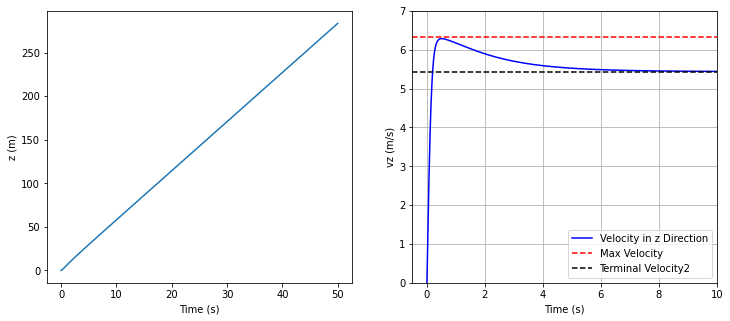

In [7]:
fig, axes = plt.subplots(1,2)
fig.set_size_inches(12,5)
axes[0].plot(t, z)
axes[0].set_ylabel('z (m)')
axes[0].set_xlabel('Time (s)')
axes[1].plot(t, vz, color ='b' ,label = 'Velocity in z Direction')
axes[1].axhline(6.33955834, color = 'r', linestyle = '--', label = 'Max Velocity')
axes[1].axhline(5.43957957, color = 'black', linestyle = '--', label = 'Terminal Velocity2')
axes[1].set_xlim(-0.5,10)
axes[1].set_ylim(0,7)
axes[1].set_ylabel('vz (m/s)')
axes[1].set_xlabel('Time (s)')
plt.legend()
plt.grid()

The balloon reaches a maximum velocity, and then comes back down to reach the terminal velocity (lower than before at 5.43957957m/s) at around 7s

where $d = 10$m is a length determining the change in height.

* **1k (10pt):** Rewrite your program to include this effect and plot the velocity and position as functions of time. What is the terminal velocity of the balloon now?

### Exercise 2: Mathematical pendulum (85pt)

A mathematical pendulum consists of a point mass $m$ suspended by a
massless thread/rod of length $l$ in a gravitational field, as shown
in the figure here. The constraining force is labeled by $\boldsymbol{T}$ and
the gravitational force is labeled $\boldsymbol{F}_g$.  Homework assignments 6 and 7 may be useful to study here. Taylor chapter 5 is the relevant reference for this exercise.

<!-- dom:FIGURE: [figures/Simplependulum.png, width=600 frac=0.6]  -->
<!-- begin figure -->

<img src="figures/Simplependulum.png" width="600"><p style="font-size: 0.9em"><i>Figure 1: </i></p>
<!-- end figure -->

We assume that the length $l$ is constant and we define the coordinates involved as

$$
\boldsymbol{r} = l\sin(\phi)\boldsymbol{i}+l\cos(\phi)\boldsymbol{j},
$$

where $\boldsymbol{i}$ and $\boldsymbol{j}$ are the unit vectors in the $x$ and $y$ directions, respectively.

* **2a (10pt):** Set up the forces acting on the system and show that the equation of motion is $m\ddot{\boldsymbol{r}}=\boldsymbol{F}_g+\boldsymbol{T}$.

Transforming to polar coordinates $r$ and $\phi$, 
the equation for $\phi$ is a second-order differential equation (you don't need to show this)

$$
\ddot{\phi}(t)=-\omega_0^2\sin{(\phi(t))}.
$$

This equation can be solved analytically if we assume that the angle $\phi$ is very small. Then we can approximate our equation as

$$
\ddot{\phi}(t)=-\omega_0^2\phi(t).
$$

* **2b (10pt):** Find the analytical solution for the last equation. Hint, look back at the solutions for the simple harmonic oscillator problem in one dimension in for example homework 6 and chapter 5 of Taylor.

For our numerical treatment of the full second-order differential  equation, we can proceed as we have done before and split the second-order differential in two first-order differential equations
as shown here

$$
\frac{d\dot{\phi}}{dt}=-\omega_0^2\sin{(\phi)}.
$$

and

$$
\frac{d\phi}{dt}=\dot{\phi}.
$$

* **2c (10pt):** Scale the equations in terms of a dimensionless time $\hat{t}=\omega_0t$. Choose between the Euler-Cromer, the Velocity-Verlet or the Runge-Kutta to fourth order and **write down** the algorithm for solving the last two equations numerically. Explain briefly your choice of numerical algorithm. Hint, look back at what you did in homework assignments 6 and 7 and the  midterms.

* **2d (15pt):** Choose initial conditions and compare your numerical solution with the analytical one. For which range of angles $\phi$ (determined by your initial conditions) are the analytical solutions comparable to your numerical results? Discuss the implications of your results.

* **2e (20pt):** Find the expressions for the kinetic and potential energies in terms of the variables $r$ and $\phi$. Remember that $r=l$ and is a constant throughout the calculations. In your code, check then whether energy is conserved by calculating the total energy, the kinetic and potential energies ad functions of time. Discuss your results. Do you expect energy to be conserved? 

* **2f (20pt):** With the potential $V$  and kinetic $T$ energy, define the Lagrangian for the mathematical pendulum discussed here. Add the constraint $r=l$ via a Lagrange multiplier $\lambda$ and derive the equations of motion. Show that these result in  $\ddot{\phi}(t)=-\omega_0^2\sin{(\phi(t))}$ with $\omega_0^2=g/l$ and $\lambda=ml\dot{\phi}^2+mg\cos{(\phi)}$.  How would you interpret $\lambda$?

#### 2c

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from math import *

In [14]:
def SpringForce(v,phi,t):
#   note here that we have divided by mass and we return the acceleration
    return  -np.sin(phi)

In [15]:
def RK4(v,phi,t,n,Force):
    for i in range(n-1):
# Setting up k1
        k1phi = DeltaT*v[i]
        k1v = DeltaT*Force(v[i],phi[i],t[i])
# Setting up k2
        vv = v[i]+k1v*0.5
        phiphi = phi[i]+k1phi*0.5
        k2phi = DeltaT*vv
        k2v = DeltaT*Force(vv,phiphi,t[i]+DeltaT*0.5)
# Setting up k3
        vv = v[i]+k2v*0.5
        phiphi = phi[i]+k2phi*0.5
        k3phi = DeltaT*vv
        k3v = DeltaT*Force(vv,phiphi,t[i]+DeltaT*0.5)
# Setting up k4
        vv = v[i]+k3v
        phiphi = phi[i]+k3phi
        k4phi = DeltaT*vv
        k4v = DeltaT*Force(vv,phiphi,t[i]+DeltaT)
# Final result
        phi[i+1] = phi[i]+(k1phi+2*k2phi+2*k3phi+k4phi)/6.
        v[i+1] = v[i]+(k1v+2*k2v+2*k3v+k4v)/6.
        t[i+1] = t[i] + DeltaT

The main advantage of the Runge-Kutta method is that it is a higher-order method, which means that it is more accurate than lower-order methods like the Euler-Cromer method. However, it can be more computationally expensive than lower-order methods.

#### 2d

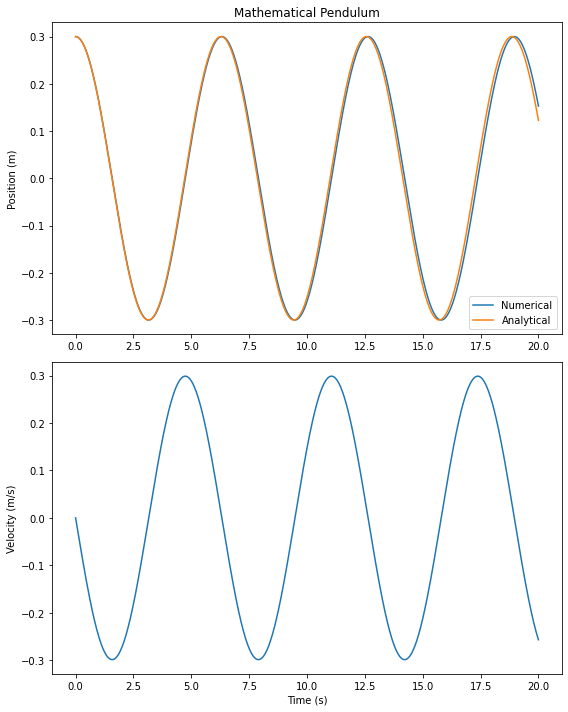

In [19]:
DeltaT = 0.001
#set up arrays 
tfinal = 20 # in dimensionless time
n = ceil(tfinal/DeltaT)
# set up arrays for t, v, and x
t = np.zeros(n)
v = np.zeros(n)
phi = np.zeros(n)
# Initial conditions (can change to more than one dim)
phi0 = 0.3
v0 = 0
phi[0] = phi0
v[0] = v0
# Start integrating using the RK4 method
# Note that we define the force function as a SpringForce
RK4(v,phi,t,n,SpringForce)

# Plot position and velocity as function of time    
analytical_phi = phi0*np.cos(t)
fig, ax = plt.subplots(2,1)
fig.set_size_inches(8,10)
ax[0].set_title('Mathematical Pendulum')
ax[0].plot(t,phi, label='Numerical')
ax[0].plot(t,analytical_phi, label='Analytical')
ax[0].legend()
ax[1].plot(t,v)
ax[1].set_xlabel('Time (s)')
ax[0].set_ylabel('Position (m)')
ax[1].set_ylabel('Velocity (m/s)')
fig.tight_layout()
plt.show()

For angles < 0.3 radians, the numerical solution is comparable to the anlytical solution. The fact that the numerical solution is only similar to the analytical solution for small angles has important implications for the behavior of the pendulum.

For small angles, the sine function can be approximated by its argument, which leads to the linear differential equation $\ddot{\phi}(t) \approx -\omega_0^2\phi(t)$, where $\omega_0^2 = g/l$ is the natural frequency of the pendulum. This linear differential equation can be solved analytically and gives the well-known result that the period of the pendulum is given by $T = 2\pi\sqrt{l/g}$.

However, for larger angles, the sine function cannot be approximated by its argument, and the motion of the pendulum becomes more complicated. The numerical solution shows that the period of the pendulum is not constant, but rather depends on the amplitude of the oscillation. This phenomenon is known as nonlinear behavior, and is a common feature of many physical systems.

In the case of the pendulum, the nonlinearity arises from the fact that the gravitational force depends on the angle $\phi$, which in turn affects the tension in the string and the centripetal force. As a result, the motion of the pendulum is influenced by both linear and nonlinear forces, which leads to the complicated behavior observed for large angles.

In conclusion, the fact that the numerical solution is only similar to the analytical solution for small angles highlights the importance of understanding the nonlinear behavior of physical systems. While linear approximations can be useful for understanding simple systems, many real-world systems exhibit nonlinear behavior, and a more sophisticated understanding is required to accurately model their behavior.

#### 2e

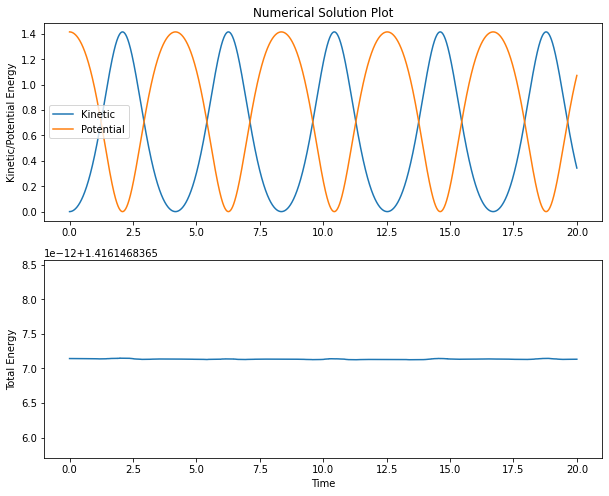

In [12]:
fig, ax = plt.subplots(2,1)
fig.set_size_inches(10,8)
ax[0].plot(t,1/2*v**2,label='Kinetic')
ax[0].plot(t,1-np.cos(phi),label='Potential')
ax[1].plot(t,1/2*v**2+1-np.cos(phi))
ax[0].set_title('Numerical Solution Plot')
ax[0].set_ylabel('Kinetic/Potential Energy')
ax[1].set_ylabel('Total Energy')
ax[1].set_xlabel('Time')
ax[0].legend();

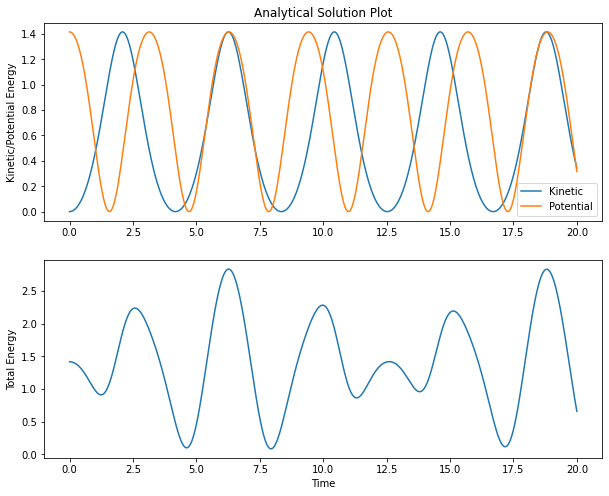

In [13]:
fig, ax = plt.subplots(2,1)
fig.set_size_inches(10,8)
ax[0].plot(t,1/2*v**2, label='Kinetic')
ax[0].plot(t,1-np.cos(analytical_phi), label='Potential')
ax[1].plot(t,1/2*v**2+1-np.cos(analytical_phi))
ax[0].set_title('Analytical Solution Plot')
ax[0].set_ylabel('Kinetic/Potential Energy')
ax[1].set_ylabel('Total Energy')
ax[1].set_xlabel('Time')
ax[0].legend();

In general, energy is not conserved for large angles, and the conservation of energy becomes less accurate as the angle increases.

For small angles, the motion of the pendulum can be approximated as a linear oscillator, and the kinetic and potential oscillate opposite to each other over time. In this case, the conservation of energy is very accurate and the total energy of the system remains constant over time.

However, for larger angles, the potential energy becomes more nonlinear, and the conservation of energy becomes less accurate. This is because the potential energy is no longer well-approximated. As a result, the motion of the pendulum becomes more complicated and the conservation of energy becomes less accurate.

### Classical Mechanics Extra Credit Assignment: Scientific Writing and attending Talks

The following gives you an opportunity to earn **five extra credit
points** on each of the remaining homeworks and **ten extra credit points**
on the midterms and finals.  This assignment also covers an aspect of
the scientific process that is not taught in most undergraduate
programs: scientific writing.  Writing scientific reports is how
scientist communicate their results to the rest of the field.  Knowing
how to assemble a well written scientific report will greatly benefit
you in you upper level classes, in graduate school, and in the work
place.

The full information on extra credits is found at <https://github.com/mhjensen/Physics321/blob/master/doc/Homeworks/ExtraCredits/>. There you will also find examples on how to write a scientific article. 
Below you can also find a description on how to gain extra credits by attending scientific talks.

This assignment allows you to gain extra credit points by practicing
your scientific writing.  For each of the remaining homeworks you can
submit the specified section of a scientific report (written about the
numerical aspect of the homework) for five extra credit points on the
assignment.  For the two midterms and the final, submitting a full
scientific report covering the numerical analysis problem will be
worth ten extra points.  For credit the grader must be able to tell
that you put effort into the assignment (i.e. well written, well
formatted, etc.).  If you are unfamiliar with writing scientific
reports, [see the information here](https://github.com/mhjensen/Physics321/blob/master/doc/Homeworks/ExtraCredits/IntroductionScientificWriting.md)

The following table explains what aspect of a scientific report is due
with which homework.  You can submit the assignment in any format you
like, in the same document as your homework, or in a different one.
Remember to cite any external references you use and include a
reference list.  There are no length requirements, but make sure what
you turn in is complete and through.  If you have any questions,
please contact us.

<table class="dotable" border="1">
<thead>
<tr><th align="center">  HW/Project </th> <th align="center">Due Date</th> <th align="center">Extra Credit Assignment</th> </tr>
</thead>
<tbody>
<tr><td align="center">   HW 3             </td> <td align="center">   2-8         </td> <td align="center">   Abstract                   </td> </tr>
<tr><td align="center">   HW 4             </td> <td align="center">   2-15        </td> <td align="center">   Introduction               </td> </tr>
<tr><td align="center">   HW 5             </td> <td align="center">   2-22        </td> <td align="center">   Methods                    </td> </tr>
<tr><td align="center">   HW 6             </td> <td align="center">   3-1         </td> <td align="center">   Results and Discussion     </td> </tr>
<tr><td align="center">   **Midterm 1**    </td> <td align="center">   **3-12**    </td> <td align="center">   *Full Written Report*      </td> </tr>
<tr><td align="center">   HW 7             </td> <td align="center">   3-22        </td> <td align="center">   Abstract                   </td> </tr>
<tr><td align="center">   HW 8             </td> <td align="center">   3-29        </td> <td align="center">   Introduction               </td> </tr>
<tr><td align="center">   HW 9             </td> <td align="center">   4-5         </td> <td align="center">   Results and Discussion     </td> </tr>
<tr><td align="center">   **Midterm 2**    </td> <td align="center">   **4-16**    </td> <td align="center">   *Full Written Report*      </td> </tr>
<tr><td align="center">   HW 10            </td> <td align="center">   4-26        </td> <td align="center">   Abstract                   </td> </tr>
<tr><td align="center">   **Final**        </td> <td align="center">   **4-30**    </td> <td align="center">   *Full Written Report*      </td> </tr>
</tbody>
</table>

You can also gain extra credits if you attend scientific talks.
This is described here.

### Integrating Classwork With Research

This opportunity will allow you to earn up to 5 extra credit points on a Homework per week. These points can push you above 100% or help make up for missed exercises.
In order to earn all points you must:

1. Attend an MSU research talk (recommended research oriented Clubs is  provided below)

2. Summarize the talk using at least 150 words

3. Turn in the summary along with your Homework.

Approved talks:
Talks given by researchers through the following clubs:
* Research and Idea Sharing Enterprise (RAISE)​: Meets Wednesday Nights Society for Physics Students (SPS)​: Meets Monday Nights

* Astronomy Club​: Meets Monday Nights

* Facility For Rare Isotope Beam (FRIB) Seminars: ​Occur multiple times a week

All the material on extra credits is at <https://github.com/mhjensen/Physics321/blob/master/doc/Homeworks/ExtraCredits/>.